# Alberta Electricity Price Predictor - Model Training

**Objective:** Beat the AESO forecast - MAE < 22.63 $/MWh

**Baseline:** AESO MAE = 22.63 $/MWh

## Sections
- Section 1 - Load data from PostgreSQL
- Section 2 - Baseline comparison
- Section 3 - Train/Test split
- Section 4 - XGBoost model
- Section 5 - Evaluation vs AESO
- Section 6 - Feature importance

In [28]:
# 📦 Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os,sys 
from pathlib import Path
from dotenv import load_dotenv

# 🤖 ML libraries
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 🎨 Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

load_dotenv()
print("✅ Libraries loaded")

✅ Libraries loaded


## Section 1 - Load Data

We load directly from the features table in PostgreSQL.
This table already has all ML features pre-computed.

In [29]:
# 📥 Load features from PostgreSQL
engine = create_engine(
  f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
  f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

df = pd.read_sql(
  "SELECT * FROM features ORDER BY timestamp_utc ASC",
  engine
)

# 📅 Set timestamp as index
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
df = df.set_index("timestamp_utc")

print(f"✅ Loaded {len(df):,} rows")
print(f"📅 From : {df.index.min()}")
print(f"📅 To   : {df.index.max()}")
print(f"📋 Columns : {list(df.columns)}")


✅ Loaded 54,420 rows
📅 From : 2020-01-08 07:00:00+00:00
📅 To   : 2026-03-24 18:00:00+00:00
📋 Columns : ['price_actual', 'price_forecast', 'consumption_actual', 'hour_local', 'month', 'day_of_week', 'is_weekend', 'price_lag_1h', 'price_lag_2h', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_7d', 'price_rolling_30d', 'total_generation_mw', 'export_to_bc', 'export_to_mt', 'export_to_sk', 'import_from_bc', 'import_from_mt', 'import_from_sk']


## Section 2 - Baseline Comparison

Before training any model — establish what we need to beat.

| Baseline | MAE | Description |
|----------|-----|-------------|
| Naive (mean) | ? | Always predict the historical mean |
| Lag 1h | ? | Always predict last hour's price |
| AESO forecast | 22.63$/MWh | Official AESO prediction |

In [30]:
# 📊 Baseline comparison
from sklearn.metrics import mean_absolute_error

# 🧹 Drop rows where price_actual or price_forecast is NULL
df_model = df.dropna(subset=["price_actual", "price_forecast", "price_lag_1h"]).copy()
print(f"📐 Rows after dropping NULLs : {len(df_model):,}")

# 🔵 Naive baseline — always predict the historical mean
mean_price = df_model["price_actual"].mean()
mae_naive  = mean_absolute_error(df_model["price_actual"],
                                  [mean_price] * len(df_model))

# 🟡 Lag 1h baseline — always predict last hour's price
mae_lag1 = mean_absolute_error(
  df_model["price_actual"],
  df_model["price_lag_1h"]
)

# 🔴 AESO baseline — official forecast
mae_aeso = mean_absolute_error(df_model["price_actual"], df_model["price_forecast"])

print("\n📊 Baseline comparison :")
print(f"   🔵 Naive (mean price)  : {mae_naive:.2f} $/MWh")
print(f"   🟡 Lag 1h              : {mae_lag1:.2f} $/MWh")
print(f"   🔴 AESO forecast       : {mae_aeso:.2f} $/MWh")
print(f"\n🎯 Our target           : MAE < {mae_aeso:.2f} $/MWh")

📐 Rows after dropping NULLs : 54,419

📊 Baseline comparison :
   🔵 Naive (mean price)  : 81.98 $/MWh
   🟡 Lag 1h              : 29.22 $/MWh
   🔴 AESO forecast       : 22.68 $/MWh

🎯 Our target           : MAE < 22.68 $/MWh


In [39]:
# 📋 Define features and target
from src.build_features import FeatureBuilder

FEATURES = FeatureBuilder.FEATURES
TARGET   = FeatureBuilder.TARGET

# 📅 Time-based split — train on past, test on future
train = df_model[df_model.index < "2025-01-01"]
test  = df_model[df_model.index >= "2025-01-01"]

# 🔀 Separate features and target
X_train = train[FEATURES]
y_train = train[TARGET]

X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"📊 Train : {len(X_train):,} rows ({len(X_train)/len(df_model)*100:.0f}%)")
print(f"📊 Test  : {len(X_test):,} rows  ({len(X_test)/len(df_model)*100:.0f}%)")
print(f"📋 Features : {len(FEATURES)}")
print(f"📅 Train period : {train.index.min()} → {train.index.max()}")
print(f"📅 Test period  : {test.index.min()} → {test.index.max()}")

📊 Train : 43,673 rows (80%)
📊 Test  : 10,746 rows  (20%)
📋 Features : 20
📅 Train period : 2020-01-08 07:00:00+00:00 → 2024-12-31 23:00:00+00:00
📅 Test period  : 2025-01-01 00:00:00+00:00 → 2026-03-24 17:00:00+00:00


## Section 4 - XGBoost Model

Strategy : train with reasonable parameters first.
If we beat the AESO baseline → tune with Optuna.
If not → fix the fundamentals first.

Parameters :
- n_estimators = 1000 (max trees — early stopping will find the best)
- learning_rate = 0.05 (small steps — more precise)
- max_depth = 6 (balanced complexity)
- early_stopping_rounds = 50 (stops automatically when no improvement)

In [45]:
# 🤖 Train XGBoost model
from xgboost import XGBRegressor

model = XGBRegressor(
  n_estimators          = 1000,  # 📊 Maximum number of trees
  learning_rate         = 0.05,  # 🐢 Small steps — more precise
  max_depth             = 6,     # 🌳 Balanced tree depth
  early_stopping_rounds = 50,    # 🛑 Stop if no improvement for 50 rounds
  eval_metric           = "mae", # 📏 Optimize for MAE
  random_state          = 42,    # 🎲 Reproducibility
  n_jobs                = -1,    # ⚡ Use all CPU cores
)

print("🤖 Training XGBoost...")
print(f"📊 Train size : {len(X_train):,} rows")
print(f"📊 Test size  : {len(X_test):,} rows")
print(f"📋 Features   : {len(FEATURES)}")
print()

model.fit(
  X_train, y_train,
  eval_set = [(X_test, y_test)],  # 📊 Monitor test MAE during training
  verbose  = 100,                  # 🖨️ Print every 100 rounds
)

print(f"\n✅ Training complete")
print(f"🌳 Best iteration : {model.best_iteration}")

🤖 Training XGBoost...
📊 Train size : 43,673 rows
📊 Test size  : 10,746 rows
📋 Features   : 20

[0]	validation_0-mae:82.14147
[100]	validation_0-mae:13.89552
[168]	validation_0-mae:14.70531

✅ Training complete
🌳 Best iteration : 118


## Section 5 - Evaluation vs AESO

In [46]:
# 📊 Official evaluation
y_pred = model.predict(X_test)

# 📏 MAE — overall
mae_xgboost = mean_absolute_error(y_test, y_pred)

# 📏 MAE — on spikes only (price > 300$/MWh)
spike_mask      = y_test > 300
mae_xgb_spikes  = mean_absolute_error(y_test[spike_mask], y_pred[spike_mask])
mae_aeso_spikes = mean_absolute_error(
  y_test[spike_mask],
  test.loc[spike_mask, "price_forecast"]
)

print("📊 Final evaluation :")
print(f"\n   Overall MAE :")
print(f"   🔵 Naive        : {mae_naive:.2f} $/MWh")
print(f"   🟡 Lag 1h       : {mae_lag1:.2f} $/MWh")
print(f"   🔴 AESO         : {mae_aeso:.2f} $/MWh")
print(f"   🏆 XGBoost      : {mae_xgboost:.2f} $/MWh")

print(f"\n   Spikes only (price > 300$/MWh) :")
print(f"   🔴 AESO         : {mae_aeso_spikes:.2f} $/MWh")
print(f"   🏆 XGBoost      : {mae_xgb_spikes:.2f} $/MWh")
print(f"   📊 Spike hours  : {spike_mask.sum():,} ({spike_mask.mean()*100:.1f}%)")

improvement = (mae_aeso - mae_xgboost) / mae_aeso * 100
print(f"\n🎯 Improvement vs AESO : {improvement:.1f}%")

📊 Final evaluation :

   Overall MAE :
   🔵 Naive        : 81.98 $/MWh
   🟡 Lag 1h       : 29.22 $/MWh
   🔴 AESO         : 22.68 $/MWh
   🏆 XGBoost      : 13.87 $/MWh

   Spikes only (price > 300$/MWh) :
   🔴 AESO         : 207.83 $/MWh
   🏆 XGBoost      : 234.64 $/MWh
   📊 Spike hours  : 210 (2.0%)

🎯 Improvement vs AESO : 38.8%


## Section 5 — Evaluation vs AESO

### Results

| Model | Overall MAE | vs AESO |
|-------|-------------|---------|
| 🔵 Naive (mean) | 81.98 $/MWh | -262% |
| 🟡 Lag 1h | 29.22 $/MWh | -29% |
| 🔴 AESO forecast | 22.68 $/MWh | baseline |
| 🏆 XGBoost | 13.87 $/MWh | **+38.8% better** |

### On normal hours - XGBoost wins clearly
XGBoost is 38.8% better than AESO overall.
On the 98% of hours where prices are stable — our model is excellent.

### On spikes (price > 300$/MWh) - XGBoost loses
| Model | Spike MAE | Spike hours |
|-------|-----------|-------------|
| 🔴 AESO | 207.83 $/MWh | 210 hours (2%) |
| 🏆 XGBoost | 234.64 $/MWh | 210 hours (2%) |

XGBoost is **worse** than AESO on spikes.
This is our core business problem - spikes are exactly when Alberta families suffer.

### Why does this happen ?
54,420 training rows → only 210 are spikes (2%).
The model optimizes for the 98% normal hours.
It "sacrifices" the 2% spikes to minimize overall MAE.

### Next step - Optuna tuning + spike weighting
We need to tell the model : spikes matter more than normal hours.

In [52]:
# 📊 Find periods with spikes in test set
spike_dates = y_test[y_test > 300].index

print(f"📊 Spike hours in test set : {len(spike_dates):,}")
print(f"📅 First spike : {spike_dates[0]}")
print(f"📅 Last spike  : {spike_dates[-1]}")
print(f"\n📅 Spike months :")
print(spike_dates.to_series().resample("ME").count())

📊 Spike hours in test set : 210
📅 First spike : 2025-01-03 00:00:00+00:00
📅 Last spike  : 2026-03-10 02:00:00+00:00

📅 Spike months :
timestamp_utc
2025-01-31 00:00:00+00:00     5
2025-02-28 00:00:00+00:00    19
2025-03-31 00:00:00+00:00     2
2025-04-30 00:00:00+00:00     1
2025-05-31 00:00:00+00:00    15
2025-06-30 00:00:00+00:00    24
2025-07-31 00:00:00+00:00    12
2025-08-31 00:00:00+00:00    27
2025-09-30 00:00:00+00:00    45
2025-10-31 00:00:00+00:00    13
2025-11-30 00:00:00+00:00    25
2025-12-31 00:00:00+00:00     5
2026-01-31 00:00:00+00:00    12
2026-02-28 00:00:00+00:00     2
2026-03-31 00:00:00+00:00     3
Freq: ME, Name: timestamp_utc, dtype: int64


In [ ]:
# 🔍 Find the biggest spike day in September 2025
sep_spikes = test[
  (test.index >= "2025-09-01") &
  (test.index <= "2025-09-30") &
  (test["price_actual"] > 300)
]
biggest_spike = sep_spikes["price_actual"].idxmax()
print(f"📊 Biggest spike : {biggest_spike} — {sep_spikes['price_actual'].max():.0f}$/MWh")

📊 Biggest spike : 2025-09-08 23:00:00+00:00 — 1000$/MWh


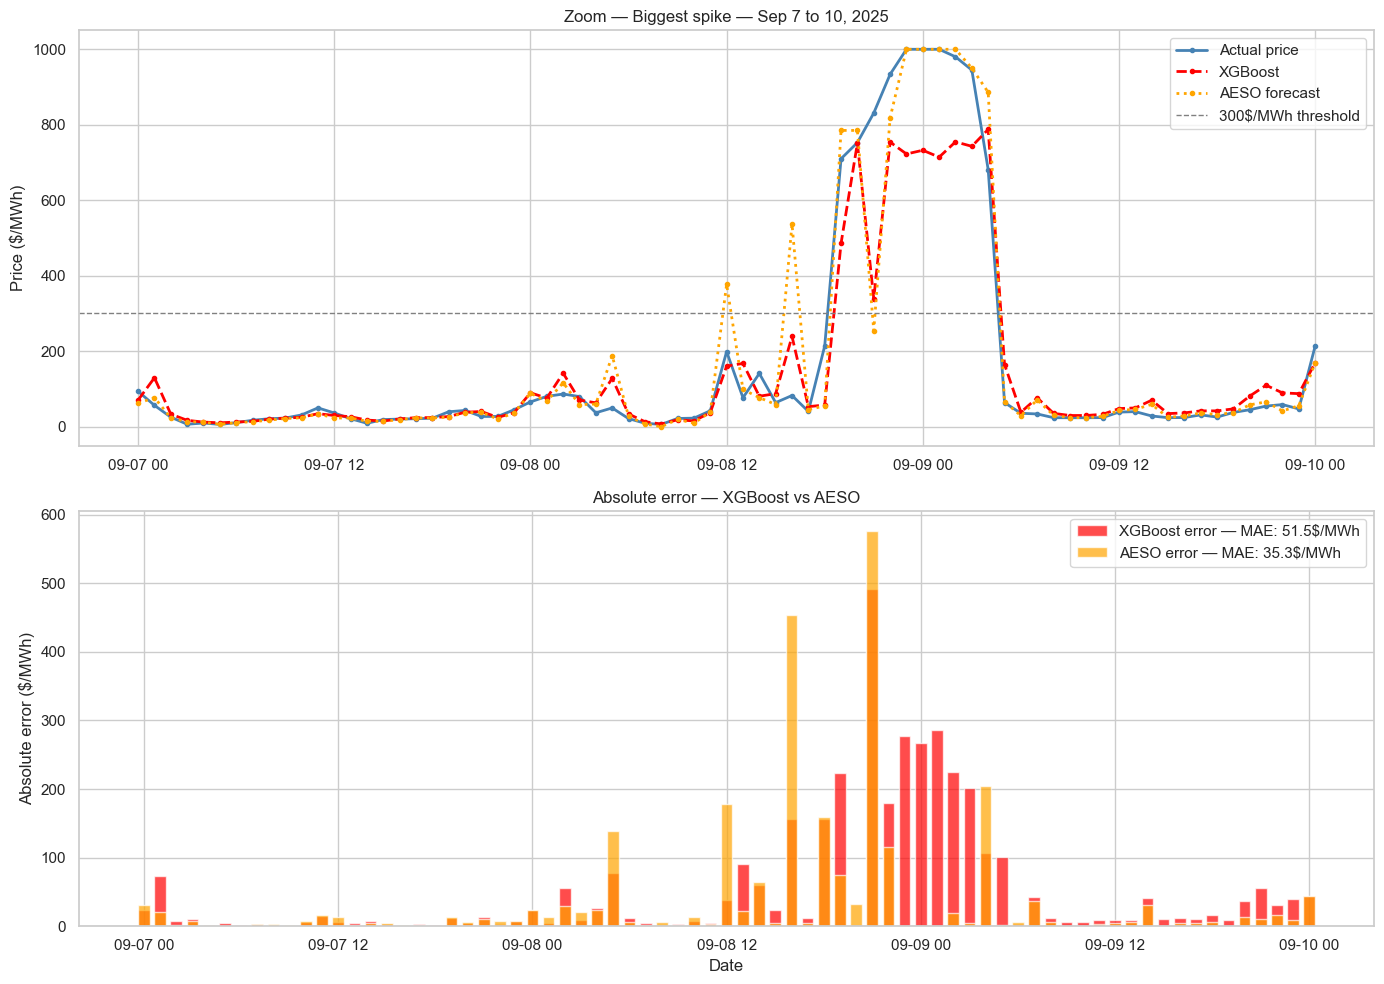

In [56]:
# 📊 Zoom — 3 days around biggest spike (Sep 7-9, 2025)
sample = test[
  (test.index >= "2025-09-07") &
  (test.index <= "2025-09-10")
].copy()

sample["prediction"] = model.predict(
    X_test[
        (X_test.index >= "2025-09-07") &
        (X_test.index <= "2025-09-10")
    ]
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 📈 Top — Price comparison
axes[0].plot(sample.index, sample["price_actual"],
             color="steelblue", linewidth=2, label="Actual price", marker="o", markersize=3)
axes[0].plot(sample.index, sample["prediction"],
             color="red", linewidth=2, linestyle="--", label="XGBoost", marker="o", markersize=3)
axes[0].plot(sample.index, sample["price_forecast"],
             color="orange", linewidth=2, linestyle=":", label="AESO forecast", marker="o", markersize=3)
axes[0].axhline(y=300, color="gray", linestyle="--", linewidth=1, label="300$/MWh threshold")
axes[0].set_title("Zoom — Biggest spike — Sep 7 to 10, 2025")
axes[0].set_ylabel("Price ($/MWh)")
axes[0].legend()

# 📈 Bottom — Error comparison
sample["error_xgb"]  = (sample["prediction"] - sample["price_actual"]).abs()
sample["error_aeso"] = (sample["price_forecast"] - sample["price_actual"]).abs()

axes[1].bar(sample.index, sample["error_xgb"],
            width=0.03, color="red", alpha=0.7,
            label=f"XGBoost error — MAE: {sample['error_xgb'].mean():.1f}$/MWh")
axes[1].bar(sample.index, sample["error_aeso"],
            width=0.03, color="orange", alpha=0.7,
            label=f"AESO error — MAE: {sample['error_aeso'].mean():.1f}$/MWh")
axes[1].set_title("Absolute error — XGBoost vs AESO")
axes[1].set_ylabel("Absolute error ($/MWh)")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()

In [57]:
# 🔍 Verify exact values around the spike
spike_window = sample[
    (sample.index >= "2025-09-08 12:00") &
    (sample.index <= "2025-09-09 06:00")
][["price_actual", "prediction", "price_forecast"]].round(1)

print(spike_window.to_string())

                           price_actual  prediction  price_forecast
timestamp_utc                                                      
2025-09-08 12:00:00+00:00         199.0  160.500000           377.4
2025-09-08 13:00:00+00:00          76.8  167.699997            98.7
2025-09-08 14:00:00+00:00         141.1   80.699997            77.1
2025-09-08 15:00:00+00:00          63.8   87.599998            58.7
2025-09-08 16:00:00+00:00          82.6  239.100006           536.8
2025-09-08 17:00:00+00:00          40.5   53.000000            45.1
2025-09-08 18:00:00+00:00         214.0   57.500000            55.4
2025-09-08 19:00:00+00:00         709.9  485.899994           785.0
2025-09-08 20:00:00+00:00         752.8  751.299988           785.0
2025-09-08 21:00:00+00:00         831.1  339.200012           254.7
2025-09-08 22:00:00+00:00         933.6  754.200012           818.5
2025-09-08 23:00:00+00:00        1000.0  722.599976          1000.0
2025-09-09 00:00:00+00:00        1000.0  732.400

### Finding — Zoom on biggest spike (Sep 8-9, 2025)

**Hour by hour analysis :**

Sep 8 12h-16h : AESO false alarms (377$, 537$ predicted vs 83-199$ actual)
                XGBoost more stable but also misses at 16h (239$ vs 83$)

Sep 8 21h: Real spike begins (actual 831$)
        Both AESO (255$) and XGBoost (339$) underestimate badly

Sep 8 23h → Sep 9 04h : Peak at 1000$/MWh (legal cap)
                AESO predicts 1000$ correctly ✅
                XGBoost plateaus at 715-787$ — underestimates by ~250$ ❌

**Root cause of XGBoost underestimation :**
The model has seen very few 1000$/MWh hours in training.
It cannot confidently predict the legal market cap.
→ Solution : spike weighting + Optuna tuning

## Section 6 - Feature Importance

Which features does XGBoost rely on the most ?
This tells us what drives price prediction.

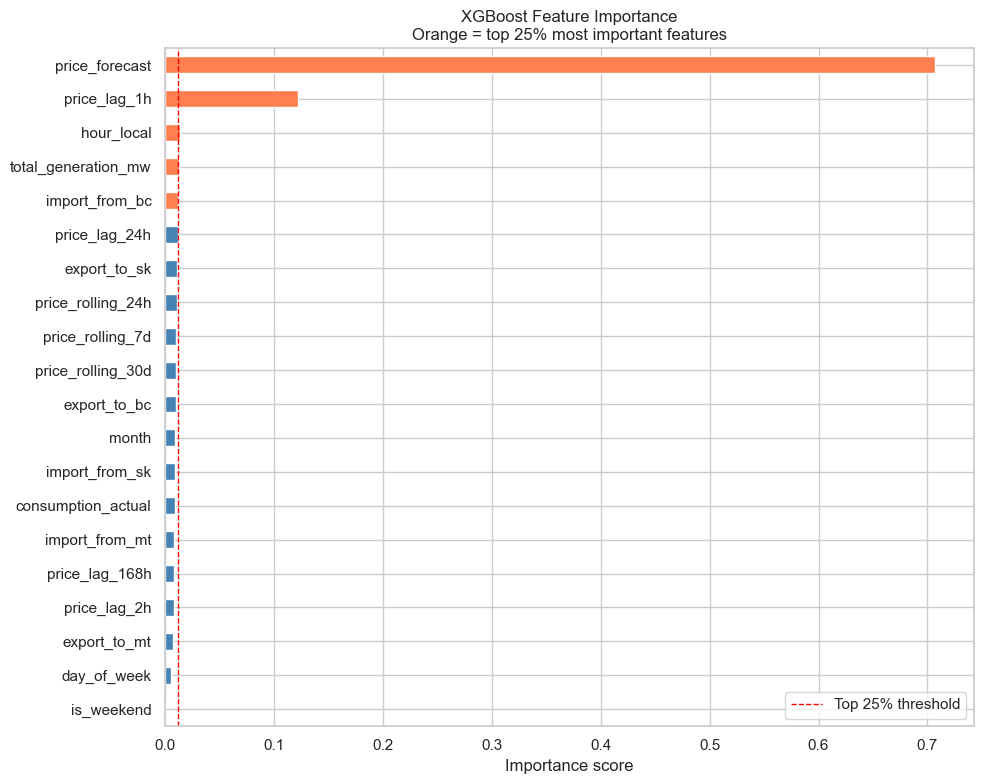

🏆 Top 5 most important features :
import_from_bc         0.0123
total_generation_mw    0.0128
hour_local             0.0142
price_lag_1h           0.1226
price_forecast         0.7073

⬇️  Bottom 5 least important features :
is_weekend        0.0000
day_of_week       0.0057
export_to_mt      0.0077
price_lag_2h      0.0083
price_lag_168h    0.0083


In [58]:
# 📊 Feature importance
fig, ax = plt.subplots(figsize=(10, 8))

# 📋 Get importance scores
importance = pd.Series(
  model.feature_importances_,
  index=FEATURES
).sort_values(ascending=True)

# 📊 Horizontal bar chart
colors = ["steelblue" if v < importance.quantile(0.75) else "coral"
          for v in importance.values]

importance.plot(kind="barh", ax=ax, color=colors)

ax.set_title("XGBoost Feature Importance\nOrange = top 25% most important features")
ax.set_xlabel("Importance score")
ax.axvline(x=importance.quantile(0.75), color="red",
           linestyle="--", linewidth=1, label="Top 25% threshold")
ax.legend()

plt.tight_layout()
plt.show()

# 📋 Print top 5 and bottom 5
print("🏆 Top 5 most important features :")
print(importance.tail(5).round(4).to_string())
print("\n⬇️  Bottom 5 least important features :")
print(importance.head(5).round(4).to_string())

## Feature Importance Findings

### Top features
- price_forecast (70%) — dominant signal — confirmed by EDA corr 0.905
- price_lag_1h (12%)   — spikes last multiple hours — confirmed by EDA
- hour_local (1.4%)    — evening peak pattern — confirmed by EDA

### Useless features — candidates for removal
- is_weekend (0%)      → no value — Alberta market doesn't follow weekend patterns
- day_of_week (0.6%)   → negligible
- price_lag_2h (0.8%)  → redundant with price_lag_1h
- price_lag_168h (0.8%)→ last week's price doesn't help predict today

### Next step — Optuna tuning
1. Remove useless features → cleaner model
2. Add spike weighting → better spike prediction
3. Tune hyperparameters → squeeze more performance